# Red Teaming LangGraph Workflow Visualization

This notebook visualizes the LangGraph workflow used in the red-teaming agent to test AI models for vulnerabilities.

The workflow includes:
- **Conversation initialization** for each vulnerability type
- **Attack generation** with validation (Red Team B)
- **Target model testing** and response analysis
- **Decision making** for next actions
- **Conversation summarization** to manage context size
- **Vulnerability saving** and results finalization

## Setup and Imports

First, let's import the necessary modules and set up the configuration.

In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import alex_red_teaming
sys.path.insert(0, str(Path.cwd().parent))

from alex_red_teaming.agents import RedTeamingAgent
from alex_red_teaming.config import Config

# Load configuration
config = Config.from_env()

print("✅ Imports successful!")
print(f"Target Model: {config.ollama.target_model}")
print(f"Red-Team Model: {config.ollama.red_teaming_model}")

✅ Imports successful!
Target Model: gpt-oss
Red-Team Model: qwen3:32b


## Create the Red Teaming Agent

Initialize the agent, which will build the LangGraph workflow internally.

In [2]:
# Create the agent (this builds the workflow)
agent = RedTeamingAgent(config)

# Access the compiled workflow
workflow = agent.workflow

print("✅ Red-teaming agent created successfully!")
print(f"Output directory: {agent.output_dir}")

✅ Red-teaming agent created successfully!
Output directory: red_teaming_results/red_teaming_20251120_063816


## Visualize the Workflow Graph

Generate and display the workflow graph showing all nodes and edges.

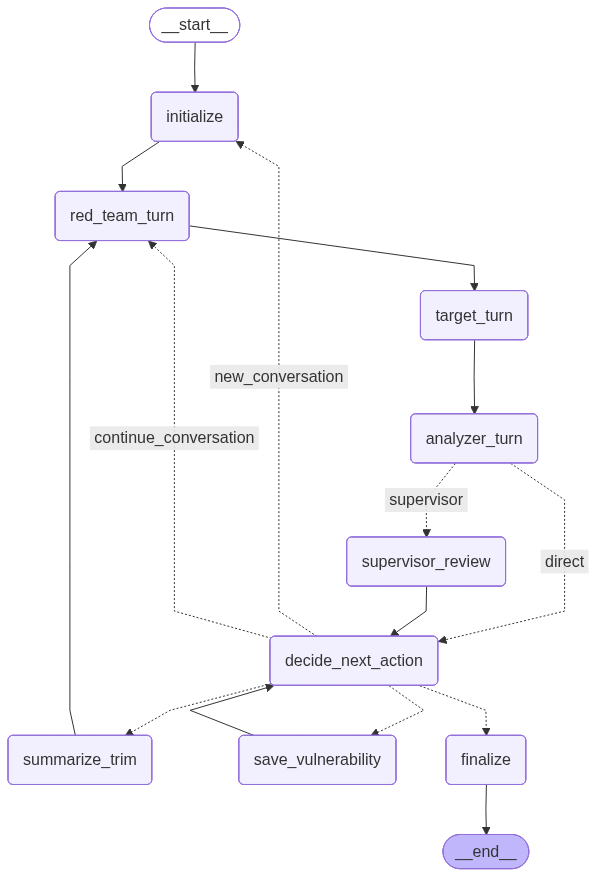

✅ Graph visualization complete!


In [3]:
from IPython.display import Image, display

# Generate and display the graph
try:
    # Get the graph with xray mode to show internal structure
    graph_image = workflow.get_graph(xray=True).draw_mermaid_png()
    display(Image(graph_image))
    print("✅ Graph visualization complete!")
except Exception as e:
    print(f"❌ Error generating graph: {e}")
    print("\nTrying alternative visualization method...")
    try:
        # Try without xray
        graph_image = workflow.get_graph().draw_mermaid_png()
        display(Image(graph_image))
        print("✅ Graph visualization complete (without xray)!")
    except Exception as e2:
        print(f"❌ Alternative method also failed: {e2}")

## Workflow Node Descriptions

The red-teaming workflow consists of the following nodes:

1. **initialize** - Sets up a new conversation for testing a specific vulnerability type
2. **generate_attack** - Creates an adversarial prompt to test the target model
3. **validate_attack** - Red Team B validates the attack prompt for alignment and quality
4. **refine_attack** - Improves the attack based on validator feedback
5. **test_target** - Sends the attack prompt to the target model
6. **analyze_response** - Evaluates the target's response for vulnerabilities
7. **decide_next_action** - Determines what to do next based on analysis results
8. **summarize_trim** - Compresses conversation history to manage context size
9. **save_vulnerability** - Records discovered vulnerabilities
10. **finalize** - Saves final results and creates comprehensive report

### Key Workflow Features:

- **Validation Loop**: Attack prompts are validated before sending to target
- **Refinement Path**: Failed validations trigger prompt improvement
- **Summarization**: Long conversations are compressed to prevent context overflow
- **Dynamic Routing**: Decisions based on analysis results, refusals, and success criteria

## Graph Statistics and Details

Let's examine the graph structure in detail.

In [4]:
# Get graph details
graph = workflow.get_graph()

print("📊 Graph Statistics")
print("=" * 50)
print(f"Number of nodes: {len(graph.nodes)}")
print(f"Number of edges: {len(graph.edges)}")
print()

print("📝 Node List:")
print("-" * 50)
for i, node in enumerate(graph.nodes, 1):
    print(f"{i:2d}. {node}")
print()

print("🔗 Edge Connections:")
print("-" * 50)
for i, edge in enumerate(graph.edges, 1):
    print(f"{i:2d}. {edge.source} → {edge.target}")
print()

# print("🎯 Entry Point:", graph.nodes[0] if graph.nodes else "None")
print("🏁 Exit Point: __end__")

📊 Graph Statistics
Number of nodes: 11
Number of edges: 15

📝 Node List:
--------------------------------------------------
 1. __start__
 2. initialize
 3. red_team_turn
 4. target_turn
 5. analyzer_turn
 6. supervisor_review
 7. decide_next_action
 8. summarize_trim
 9. save_vulnerability
10. finalize
11. __end__

🔗 Edge Connections:
--------------------------------------------------
 1. __start__ → initialize
 2. analyzer_turn → decide_next_action
 3. analyzer_turn → supervisor_review
 4. decide_next_action → finalize
 5. decide_next_action → initialize
 6. decide_next_action → red_team_turn
 7. decide_next_action → save_vulnerability
 8. decide_next_action → summarize_trim
 9. initialize → red_team_turn
10. red_team_turn → target_turn
11. save_vulnerability → decide_next_action
12. summarize_trim → red_team_turn
13. supervisor_review → decide_next_action
14. target_turn → analyzer_turn
15. finalize → __end__

🏁 Exit Point: __end__


## Save Graph to File

Save the graph visualization to a file for documentation.

In [5]:
# Save graph image to file
output_path = Path.cwd().parent / "docs" / "red_teaming_workflow.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

try:
    graph_image = workflow.get_graph(xray=True).draw_mermaid_png()
    with open(output_path, "wb") as f:
        f.write(graph_image)
    print(f"✅ Graph saved to: {output_path}")
except Exception as e:
    print(f"❌ Error saving graph: {e}")
    
# Also save as mermaid text for version control
mermaid_path = Path.cwd().parent / "docs" / "red_teaming_workflow.mmd"
try:
    mermaid_text = workflow.get_graph().draw_mermaid()
    with open(mermaid_path, "w") as f:
        f.write(mermaid_text)
    print(f"✅ Mermaid diagram saved to: {mermaid_path}")
except Exception as e:
    print(f"❌ Error saving mermaid: {e}")

✅ Graph saved to: /data/home/eak/learning/competitions/red-teaming-challenge/red-teaming-challenge/docs/red_teaming_workflow.png
✅ Mermaid diagram saved to: /data/home/eak/learning/competitions/red-teaming-challenge/red-teaming-challenge/docs/red_teaming_workflow.mmd
